In [1]:
# Setup
import marimo as mo
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"GPU Available: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("No GPU detected. Some cells may run slowly.")
    print("Go to Runtime -> Change runtime type -> GPU")

print(f"\nPython {sys.version.split()[0]}")
print(f"\nPytorch {torch.__version__}")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")


# Uncomment the line below if not using Marimo Notebook (ex. uncomment if using Jupyter/Google  Notebook)
# %matplotlib inline

GPU Available: NVIDIA GeForce RTX 5060 Laptop GPU
Memory: 8.1 GB

Python 3.13.13

Pytorch 2.11.0+cu128
Random seed set to 42


## Building ELMo from scratch

ELMo: Embeddings from Language Models

## Preparing a Small Corpus

In [2]:
# A small corpus with deliberate polysemy
corpus = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "the cat chased the dog",
    "the dog chased the cat",
    "i went to the bank to deposit money",
    "she walked to the bank to withdraw cash",
    "he sat on the bank of the river",
    "the river bank was covered with grass",
    "the cat purred on the mat",
    "the dog barked at the cat",
    "money was deposited at the bank",
    "the river bank had beautiful flowers",
    "the mat was on the floor",
    "the rug was under the dog",
    "cash was withdrawn from the bank",
    "grass grew along the river bank",
]

# Tokenize
tokenized_corpus = [sentence.split() for sentence in corpus]

# Build vocabulary
all_words = [word for sentence in tokenized_corpus for word in sentence]
word_count = Counter(all_words)
vocab = sorted(word_count.keys())
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx:word for word, idx in word_to_idx.items()}

vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")
print(f"Vocabulary: {vocab}")

Vocabulary size: 38
Vocabulary: ['along', 'at', 'bank', 'barked', 'beautiful', 'cash', 'cat', 'chased', 'covered', 'deposit', 'deposited', 'dog', 'floor', 'flowers', 'from', 'grass', 'grew', 'had', 'he', 'i', 'mat', 'money', 'of', 'on', 'purred', 'river', 'rug', 'sat', 'she', 'the', 'to', 'under', 'walked', 'was', 'went', 'with', 'withdraw', 'withdrawn']


## Simplified ELMo from Scratch

In [3]:
# Find nearest neighbors using cosine similarity
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

class SimpleELMo(nn.Module):
    """
    A simplified ELMo-style model.

    Two independent LSTMs:
    - forward LSTM: reads left-to-right
    - backward LSTM: reads right-to-left

    Their hidden states are concatenated (NOT jointly trained).
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.forward_lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.backward_lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, input_ids):
        # Get token embeddings
        embeds = self.embedding(input_ids)  # (batch, seq_len, embed_dim)

        # Forward LSTM (left-to-right)
        forward_out, _ = self.forward_lstm(embeds)

        # Backward LSTM (right-to-left) — reverse the sequence
        reversed_embeds = torch.flip(embeds, dims=[1])
        backward_out, _ = self.backward_lstm(reversed_embeds)
        backward_out = torch.flip(backward_out, dims=[1])  # Flip back

        # Concatenate (this is ELMo's "shallow bidirectionality")
        contextual = torch.cat([forward_out, backward_out], dim=-1)
        return contextual

# Create a simple ELMo
elmo = SimpleELMo(vocab_size, embedding_dim=32, hidden_dim=32)

# Get contextual representations for two sentences with "bank"
sentence1 = "i went to the bank to deposit money".split()
sentence2 = "he sat on the bank of the river".split()

ids1 = torch.tensor([[word_to_idx[w] for w in sentence1]])
ids2 = torch.tensor([[word_to_idx[w] for w in sentence2]])

with torch.no_grad():
    ctx1 = elmo(ids1)  # (1, 8, 64)
    ctx2 = elmo(ids2)  # (1, 8, 64)

# "bank" is at index 4 in both sentences
bank_repr_financial = ctx1[0, 4].numpy()
bank_repr_river = ctx2[0, 4].numpy()

sim = cosine_similarity(bank_repr_financial, bank_repr_river)
print(f"Cosine similarity between 'bank' representations:")
print(f"  Financial context vs. River context: {sim:.4f}")
print(f"\n💡 ELMo gives 'bank' DIFFERENT representations based on context!")
print(f"   (similarity < 1.0 means the vectors are different)")

Cosine similarity between 'bank' representations:
  Financial context vs. River context: 0.8320

💡 ELMo gives 'bank' DIFFERENT representations based on context!
   (similarity < 1.0 means the vectors are different)


## Visualization: ELMo

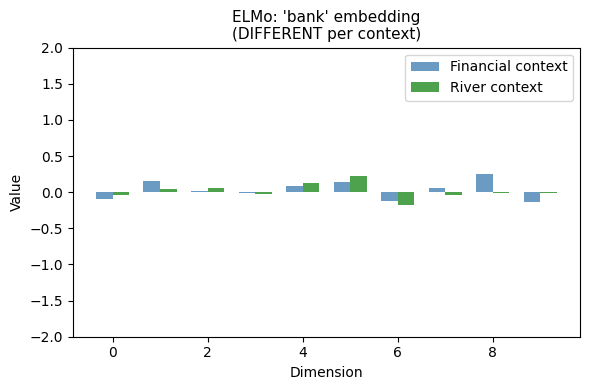

In [4]:
# 📊 Comparison: Word2Vec vs ELMo
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# ELMo: different vectors
x = np.arange(10)
width = 0.35
ax.bar(x - width/2, bank_repr_financial[:10], width, color='steelblue', alpha=0.8, label='Financial context')
ax.bar(x + width/2, bank_repr_river[:10], width, color='forestgreen', alpha=0.8, label='River context')
ax.set_title("ELMo: 'bank' embedding\n(DIFFERENT per context)", fontsize=11)
ax.set_xlabel("Dimension")
ax.set_ylabel("Value")
ax.legend()
ax.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

## Context Similarity Checker

Use the ELMo model above to check how different the representation of "bank" is in two different contexts.

In [7]:
def context_similarity(model, sentence1, sentence2, target_word, word_to_idx):
    """
    Compare the contextual representation of target_word in two sentences.

    Args:
        model: SimpleELMo model
        sentence1: first sentence (string)
        sentence2: second sentence (string)
        target_word: the word to compare (string)

    Returns:
        cosine_similarity: float between -1 and 1
        repr1: numpy array — representation in sentence 1
        repr2: numpy array — representation in sentence 2
    """
    words1 = sentence1.split()
    words2 = sentence2.split()

    # ==============================
    # Step 1: Find the index of target_word in each sentence
    # Step 2: Convert each sentence to tensor of token IDs
    # Step 3: Pass each through the model to get contextual representations
    # Step 4: Extract the representation at the target_word's position
    # Step 5: Compute cosine similarity between the two representations
    # ==============================

    idx1 = words1.index(target_word)  # position of target_word in sentence1
    idx2 = words2.index(target_word)  # position of target_word in sentence2

    ids1 = torch.tensor([[word_to_idx[w] for w in words1]])
    ids2 = torch.tensor([[word_to_idx[w] for w in words2]])

    with torch.no_grad():
        ctx1 = model(ids1)  # shape: (1, seq_len, hidden_dim)
        ctx2 = model(ids2)

    repr1 = ctx1[0, idx1, :].numpy()  # extract at idx1. shape: (hidden_dim,)
    repr2 = ctx2[0, idx2, :].numpy()  # extract at idx2. shape: (hidden_dim,)

    similarity = np.dot(repr1, repr2) / (np.linalg.norm(repr1) * np.linalg.norm(repr2))  # cosine similarity

    return similarity, repr1, repr2

In [8]:
# ✅ Verification
def _():
    sim, r1, r2 = context_similarity(
        elmo,
        "i went to the bank to deposit money",
        "he sat on the bank of the river",
        "bank",
        word_to_idx
    )
    assert isinstance(sim, (float, np.floating)), "❌ Should return a float"
    assert -1 <= sim <= 1, f"❌ Cosine similarity should be in [-1, 1], got {sim}"
    print(f"✅ Context similarity works! 'bank' similarity = {sim:.4f}")
    print(f"   (Lower similarity = model distinguishes the contexts better)")


_()

✅ Context similarity works! 'bank' similarity = 0.8320
   (Lower similarity = model distinguishes the contexts better)


# From Shallow Bidirectionality to Deep Context: ELMo → BERT

## The Core Problem with ELMo

ELMo was a major leap over Word2Vec, but it carries a fundamental architectural flaw inherited from its LSTM backbone — its bidirectionality is **shallow and disconnected**.

The forward and backward LSTMs are trained under **separate language modeling objectives**:

```
Forward LM:   P(wt | w1, w2, ..., w(t-1))   →  sees only LEFT context
Backward LM:  P(wt | w(t+1), ..., wN)        →  sees only RIGHT context
```

They never communicate during training. The two directional representations are simply **concatenated** at the end to produce the final ELMo vector. This means at no point does any single layer actually see the full sentence — left and right context are fused only at the surface level, not at the level of deep feature extraction.

Beyond shallow bidirectionality, ELMo also suffers from:

- **Sequential computation** — LSTMs process tokens one at a time, left to right (or right to left). This is inherently slow and cannot be parallelized across the sequence length, making training on large corpora expensive.
- **Long-range dependency weakness** — LSTMs struggle to carry information across very long distances in a sentence. By the time the hidden state of token 1 reaches token 50, it has been repeatedly compressed through non-linear transformations and much of the signal is lost.
- **Fixed depth fusion** — the weighted combination of LSTM layers ($\gamma \sum s_j \mathbf{h}_{k,j}$) is a relatively rigid way to aggregate multi-layer features. The weights are learned per task but the layers themselves were never trained to collaborate.

---

## What We Actually Want

The ideal model would, at **every single layer**, let each token directly attend to every other token in the sentence simultaneously — no left-only, no right-only, just full joint context from the very first layer all the way to the last. This is precisely what **self-attention** enables.

---

## How BERT Fixes This

BERT (Bidirectional Encoder Representations from Transformers), introduced by Devlin et al. (2018) at Google, replaces the LSTM stack entirely with a **Transformer encoder** built on multi-head self-attention.

The key insight is the training objective. A standard language model cannot be truly bidirectional — if the model can see the right context, it can trivially predict the current token by just looking ahead. ELMo sidesteps this by training two separate one-directional models. BERT sidesteps it more elegantly with **Masked Language Modeling (MLM)**:

```
Input:   "The river [MASK] flooded after heavy rain"
Target:  predict "bank" using ALL surrounding tokens
```

By masking 15% of tokens at random and asking the model to recover them, BERT can condition on both left and right context **jointly** at every layer without any risk of information leakage. Every transformer layer sees the full sentence simultaneously.

BERT also adds a second pretraining objective — **Next Sentence Prediction (NSP)** — to capture discourse-level relationships between sentence pairs, useful for tasks like question answering and natural language inference.

---

## ELMo vs BERT — Side by Side

| Property | ELMo | BERT |
|---|---|---|
| Architecture | Deep biLSTM | Transformer Encoder (self-attention) |
| Bidirectionality | Shallow — two separate LMs concatenated | Deep — every layer sees full context jointly |
| Training objective | Forward LM + Backward LM | Masked LM + Next Sentence Prediction |
| Parallelism | Sequential (token by token) | Fully parallel across sequence |
| Long-range dependencies | Weak — degrades over distance | Strong — direct token-to-token attention |
| Context fusion | Weighted sum of LSTM layers | Multi-head self-attention at every layer |
| Downstream usage | Weighted combination of layer outputs | Fine-tune the entire model end-to-end |

---

## The Key Conceptual Shift

The progression from Word2Vec → ELMo → BERT reflects a deepening commitment to one idea: **context should inform representation at every level, not just at the output.**

Word2Vec ignores context entirely. ELMo injects context but keeps the two directions siloed. BERT finally achieves what the field was reaching for — a model where every token, at every layer, is a function of the entire sentence.